# VIAJES DE CLIMA BUENO Y CLIMA MALO

## Analisis exploratorio

### Importacion librerias

In [40]:
from scipy import stats as st
import pandas as pd
import matplotlib.pyplot as plt

### Estudio de los datos que contienen los DataFrame

In [41]:
cabs = pd.read_csv('datasets/project_sql_result_01.csv', sep=',')
cabs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


no hay datos faltantes y no hay que cambiar el tipo de datos, estan en el formato que necesitamos

In [42]:
cabs.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


podemos visualizar que los parametros de los viajes estan en rango real

## identificar las 15 principales barrios en términos de finalización del recorrido

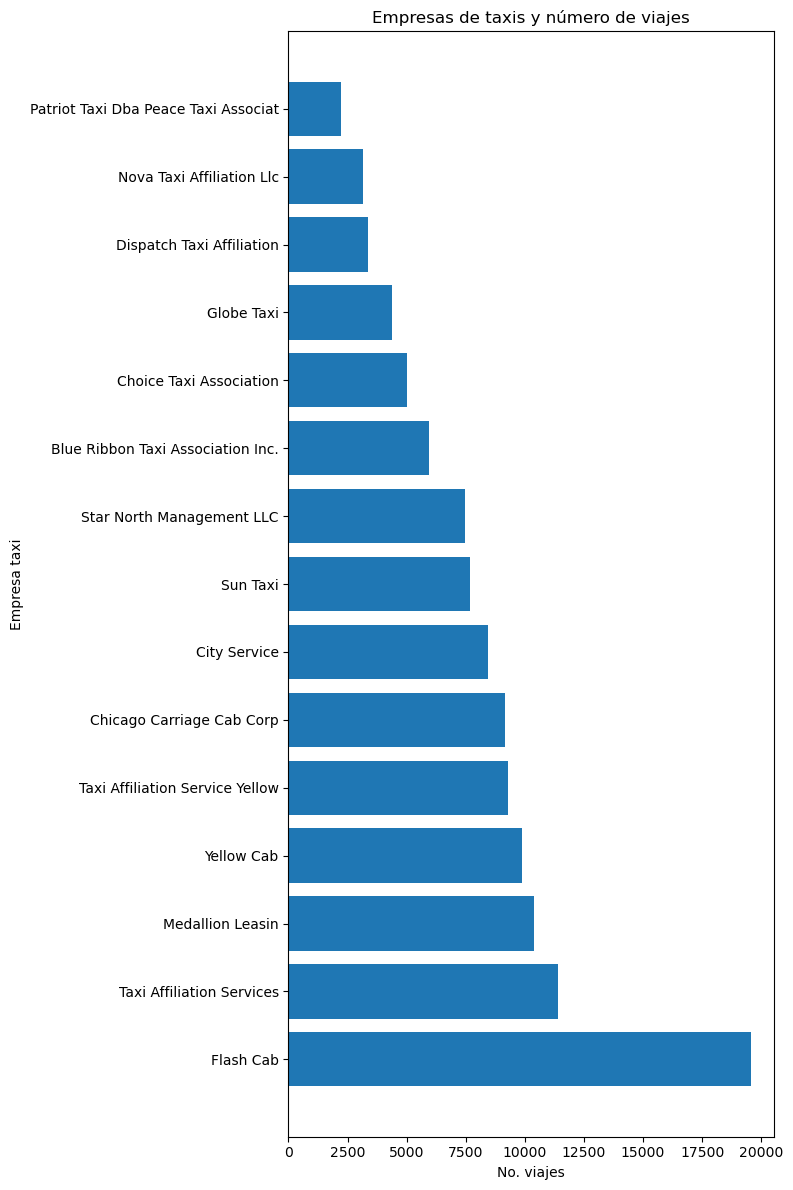

In [43]:
top_15_companies = cabs.nlargest(15, 'trips_amount')

plt.figure(figsize=(8,12))
plt.barh(top_15_companies['company_name'], top_15_companies['trips_amount'])
plt.title('Empresas de taxis y número de viajes')
plt.xlabel('No. viajes')
plt.ylabel('Empresa taxi')
plt.tight_layout()
plt.show()

In [58]:
top_15_companies.to_csv('top_15_companies.csv', index=False)

### Insight_CompañiasTaxi 
Viendo la grafica obtenida podemos ver que los viajes más soliciados son en las empresas de 'flash cab', 'Taxi Affiliation Services' & 'Medallion Leasing' podra ser que hubo algun evento en estos dias y que estos sitios de taxi eran los mas cercanos 

## LECTURA DE DATOS 'HOOD'

In [44]:
hood = pd.read_csv('datasets/project_sql_result_04.csv')
hood.info()
hood. describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [45]:
hood.head(10)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


In [46]:
top_10_hoods = hood.head(10)
print('10 principales barrios en términos de finalización del recorrido:')
print(top_10_hoods)

10 principales barrios en términos de finalización del recorrido:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


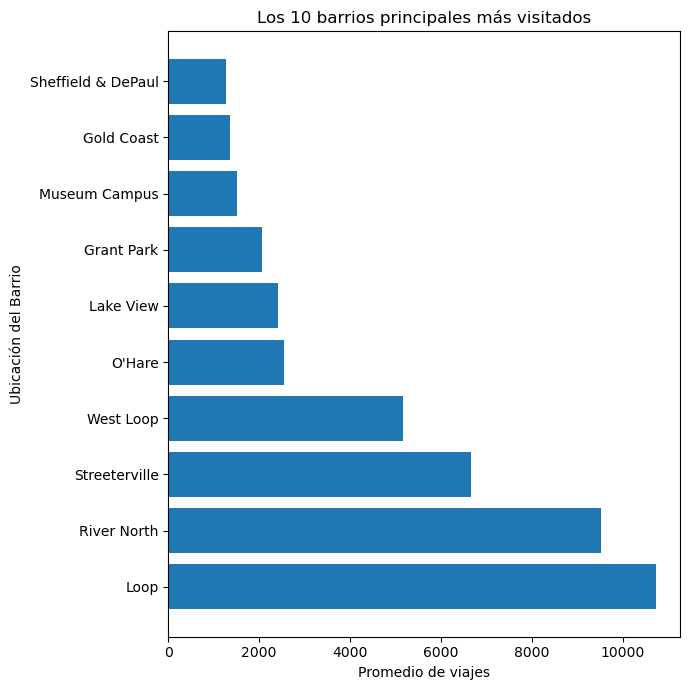

In [47]:
plt.figure(figsize=(7,7))
plt.barh(top_10_hoods['dropoff_location_name'],top_10_hoods['average_trips'])
plt.title('Los 10 barrios principales más visitados')
plt.xlabel('Promedio de viajes')
plt.ylabel('Ubicación del Barrio')
plt.tight_layout()
plt.show()

In [59]:
top_10_hoods.to_csv('top_10_hoods.csv', index=False)

### Insight_HOOD 
los barrios más visitados fueron los que tenemos en la grafica de arriba en el mes de noviembre, sera que la mayoria fueron al mismo destino pero de puntos diferente de la ciudad

## STEP 5 Prueba de Hipótesis

In [48]:
LAIO = pd.read_csv('datasets/project_sql_result_07.csv')
LAIO.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


### Aqui lo que haremos es hacer que la lista la ordenemos por los dias de la semana y que solo salgan los sabados que son los que requerimos para analizar 

In [49]:
LAIO ['start_ts'] = pd.to_datetime(LAIO['start_ts'])
LAIO['day_of_week'] = LAIO['start_ts'].dt.dayofweek
saturday = LAIO[LAIO['day_of_week'] == 5]
saturday.head()

,start_ts,weather_conditions,duration_seconds,day_of_week
0,2017-11-25 16:00:00,Good,2410.0,5
1,2017-11-25 14:00:00,Good,1920.0,5
2,2017-11-25 12:00:00,Good,1543.0,5
3,2017-11-04 10:00:00,Good,2512.0,5
4,2017-11-11 07:00:00,Good,1440.0,5


### Contaremos cuantos datos con la columna "weather_conditions" tenemos de 'Good' y cuantos de 'Bad'

In [63]:
saturday['weather_conditions'].value_counts()
saturday.to_csv('saturday_weather.csv', index=False)

### Apartir del df llamado 'saturday' que creé y nos dividio en 'Good' & 'Bad' la columna "weather_conditions" consultaremos el promedio de cada uno esto con la finalidad de cuantificar la diferencía de estos datos del sabado

In [62]:
saturday_good = saturday[saturday['weather_conditions'] == 'Good']
saturday_good.head()
print(f"promedio de tiempo con buen clima: {saturday_good['duration_seconds'].mean():.2f} segundos")


promedio de tiempo con buen clima: 1999.68 segundos


In [ ]:
saturday_bad = saturday[saturday['weather_conditions'] == 'Bad']
saturday_bad.head()
print(f"promedio de tiempo de viajes con mal clima:{saturday_bad['duration_seconds'].mean():.2f} segundos")


promedio de tiempo de viajes con mal clima:2427.21 segundos


In [ ]:
print(saturday_good.describe())
print(saturday_bad.describe())


                            start_ts  duration_seconds  day_of_week
count                            888        888.000000        888.0
mean   2017-11-11 07:45:44.594594304       1999.675676          5.0
min              2017-11-04 00:00:00          0.000000          5.0
25%              2017-11-04 14:00:00       1389.750000          5.0
50%              2017-11-11 09:00:00       1800.000000          5.0
75%              2017-11-11 16:00:00       2460.000000          5.0
max              2017-11-25 23:00:00       7440.000000          5.0
std                              NaN        759.198268          0.0
                  start_ts  duration_seconds  day_of_week
count                  180        180.000000        180.0
mean   2017-11-12 08:14:00       2427.205556          5.0
min    2017-11-04 16:00:00        480.000000          5.0
25%    2017-11-04 17:00:00       1962.000000          5.0
50%    2017-11-18 07:00:00       2540.000000          5.0
75%    2017-11-18 12:00:00       2928.00

Establecemos alpha = 0.05 
HO = nuestra hipotesis nula sera que no hay diferencias significativas entre los dias de clima bueno y los dias malo.

H1 = nuestra hipotesis alternativa sera que los viajes con mal clima duran mas tiempo.

Usaremos el criterio de la columna de 'duration_seconds' para hacer la prueba de nuestra hipotesis porque lo que estamos buscando es saber si hay una diferencia considerable entre 'La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos'.

In [54]:
alpha = 0.05
test_1 = st.ttest_ind(saturday_good['duration_seconds'],saturday_bad['duration_seconds'], equal_var=False)
print('valor p:', test_1.pvalue)
if test_1.pvalue < alpha:
    print("rechazamos la H0")
else:
    print("No podemos rechazar la H1")

valor p: 6.738994326108734e-12
rechazamos la H0


Se observa que en promedio las duración al Aeropuerto si influye mucho en el tiempo tanto meteorologico como temporal de los trayectos haciendolos más largos pudiendo ser que los conductores deban bajar la velocidad y manejar con mas precaución o porque se haga mas trafico, seria bueno proponer una ruta al Aeropuerto que pase por las zonas que se realizan mas viajes.